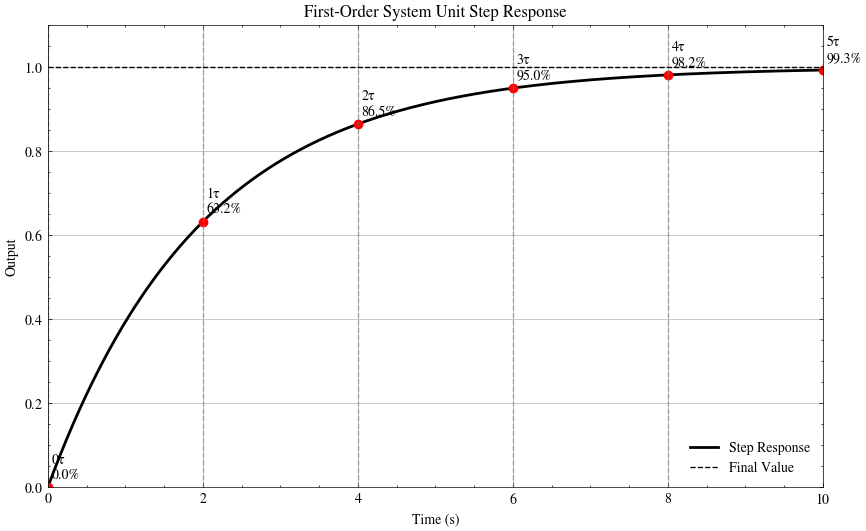

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science","no-latex"])

# Time constant
tau = 2.0  # seconds

# Time vector (up to 5 time constants)
t = np.linspace(0, 5*tau, 1000)

# Unit step response
y = 1 - np.exp(-t/tau)

# Plot
plt.figure(figsize=(10,6))
plt.plot(t, y, 'black', linewidth=2, label='Step Response')

# Mark important time constants
time_constants = np.arange(0, 6) * tau

for tc in time_constants:
    yc = 1 - np.exp(-tc/tau)

    plt.plot(tc, yc, 'ro')
    plt.axvline(tc, color='gray', linestyle='--', alpha=0.6)

    plt.text(tc + 0.05,
             yc + 0.02,
             f'{tc/tau:.0f}τ\n{yc*100:.1f}%',
             fontsize=10)

# Final value
plt.axhline(1, color='black', linestyle='--', label='Final Value')

plt.title('First-Order System Unit Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.xlim(0, 5*tau)
plt.ylim(0, 1.1)
plt.grid(True)
plt.legend()
plt.show()

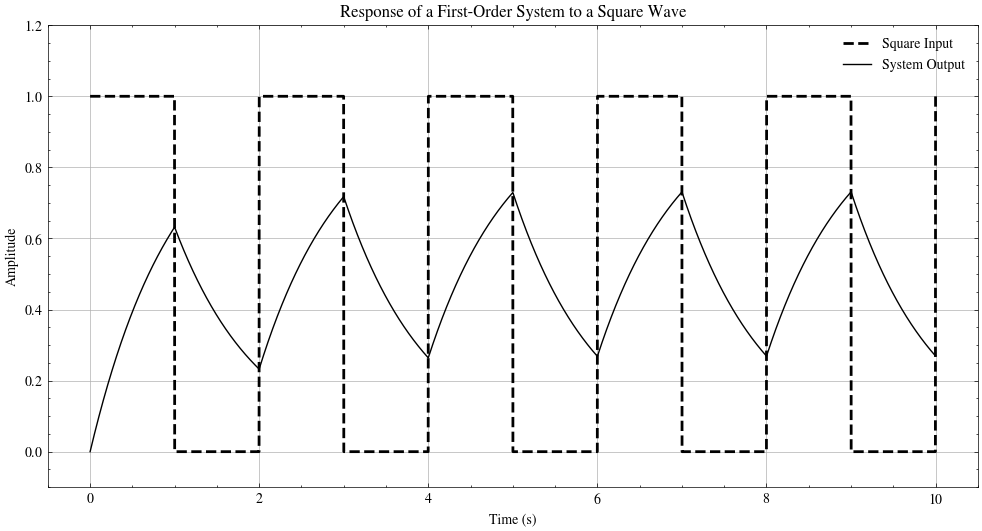

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ---------------------------------
# First-Order System Parameters
# G(s) = 1 / (tau*s + 1)
# ---------------------------------
tau = 1.0

# Time vector
t = np.linspace(0, 10, 5000)

# Square wave input
frequency = 0.5        # Hz (period = 2 s)
u = (signal.square(2*np.pi*frequency*t) + 1)/2   # Convert from (-1,1) to (0,1)

# Define first-order system
system = signal.TransferFunction([1], [tau, 1])

# Simulate response
tout, y, _ = signal.lsim(system, U=u, T=t)

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(12,6))

plt.plot(t, u, 'k--', linewidth=2, label='Square Input')
plt.plot(tout, y, 'black', linewidth=1, label='System Output')

plt.title('Response of a First-Order System to a Square Wave')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.grid(True)
plt.legend()
plt.ylim(-0.1,1.2)

plt.show()

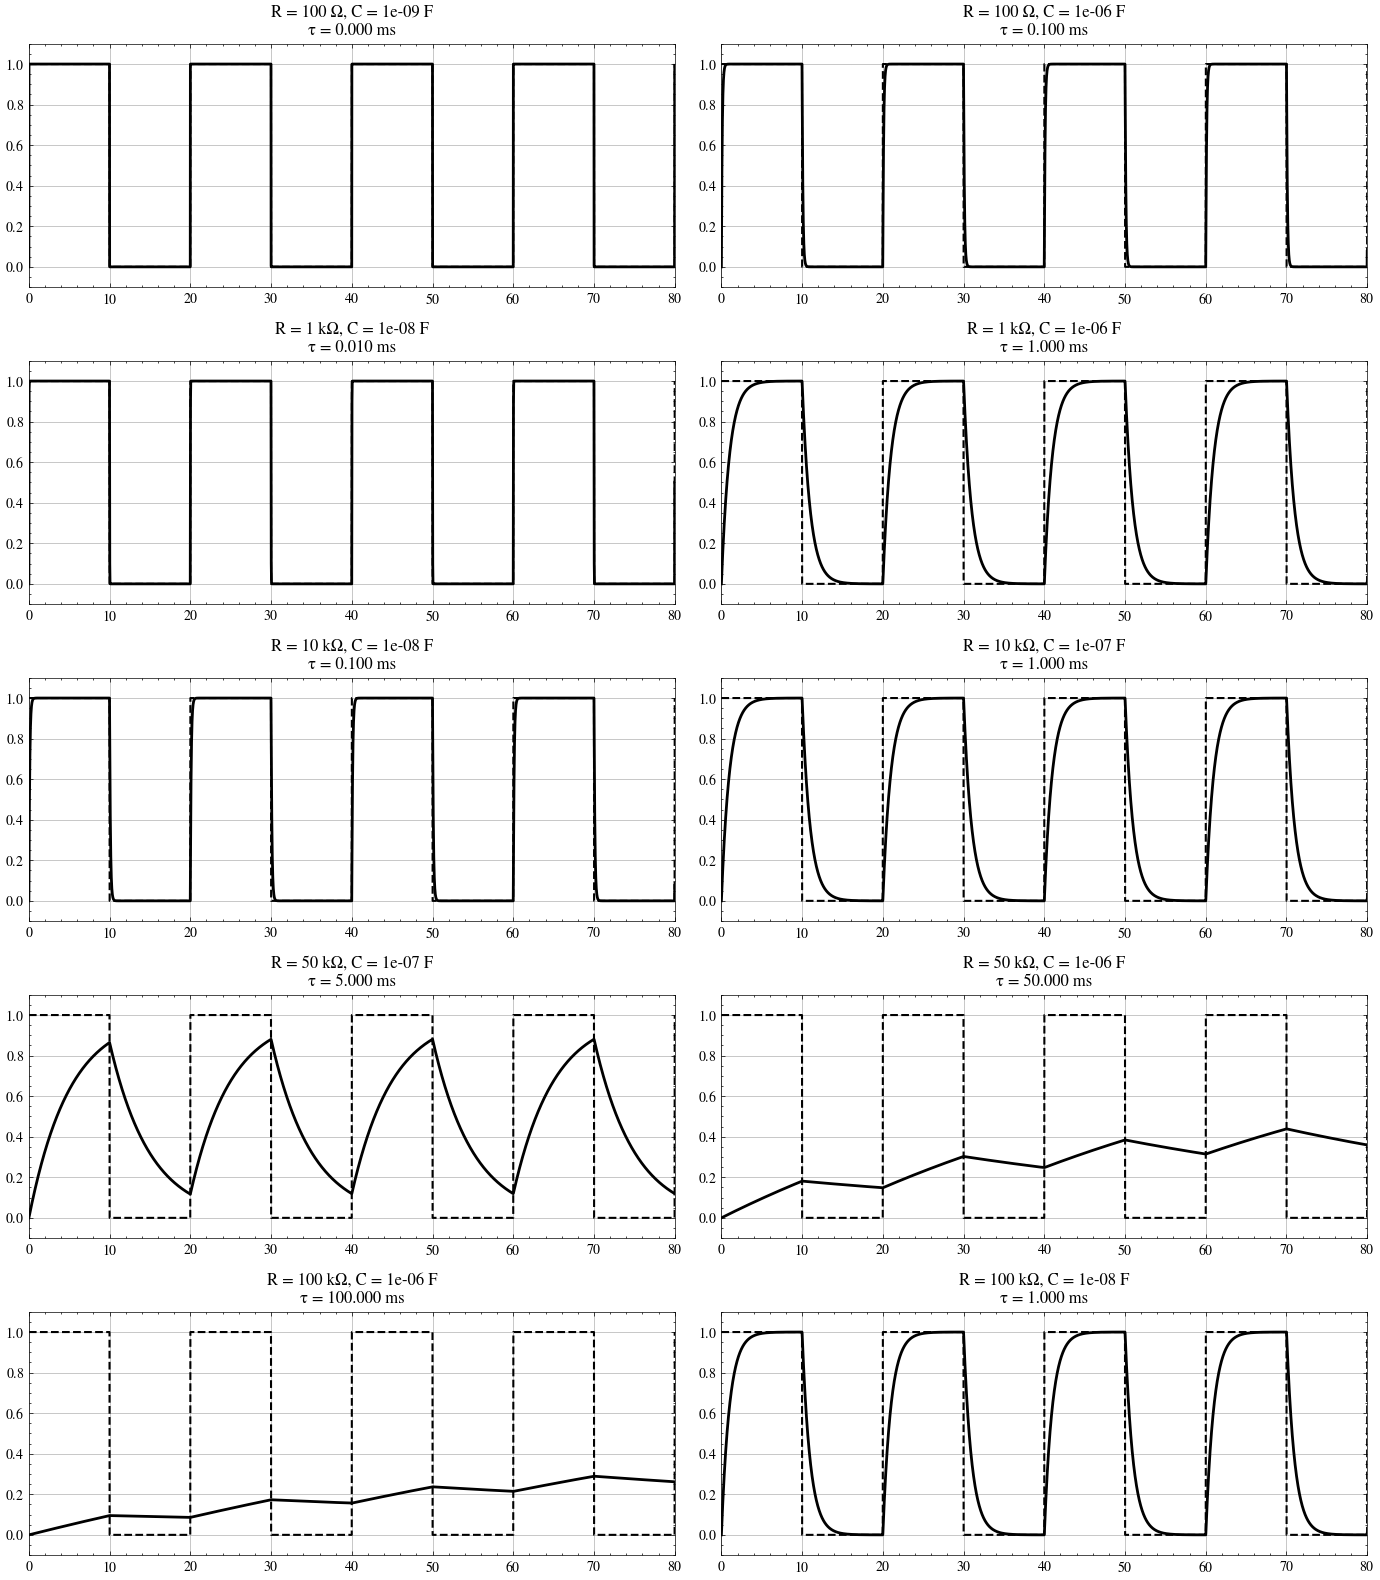

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# -------------------------------------------------
# Component values (R, C)
# -------------------------------------------------
cases = [
    ("100 Ω", 100, 1e-9),
    ("100 Ω", 100, 1e-6),
    ("1 kΩ", 1e3, 10e-9),
    ("1 kΩ", 1e3, 1e-6),
    ("10 kΩ", 10e3, 10e-9),
    ("10 kΩ", 10e3, 100e-9),
    ("50 kΩ", 50e3, 100e-9),
    ("50 kΩ", 50e3, 1e-6),
    ("100 kΩ", 100e3, 1e-6),
    ("100 kΩ", 100e3, 10e-9),
]

# -------------------------------------------------
# Simulation parameters
# -------------------------------------------------
t = np.linspace(0, 0.08, 5000)      # 80 ms
frequency = 50                      # 50 Hz square wave

# Square input (0 to 1)
u = (signal.square(2*np.pi*frequency*t)+1)/2

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(14,16))
axes = axes.ravel()

for ax, (R_label, R, C) in zip(axes, cases):

    tau = R*C

    system = signal.TransferFunction([1], [tau,1])

    tout, y, _ = signal.lsim(system, U=u, T=t)

    ax.plot(t*1000, u, 'k--', linewidth=1.5, label='Input')
    ax.plot(tout*1000, y, 'black', linewidth=2, label='Output')

    ax.set_title(f"R = {R_label}, C = {C:.0e} F\nτ = {tau*1000:.3f} ms")

    ax.set_xlim(0,80)
    ax.set_ylim(-0.1,1.1)
    ax.grid(True)

plt.tight_layout()
plt.show()

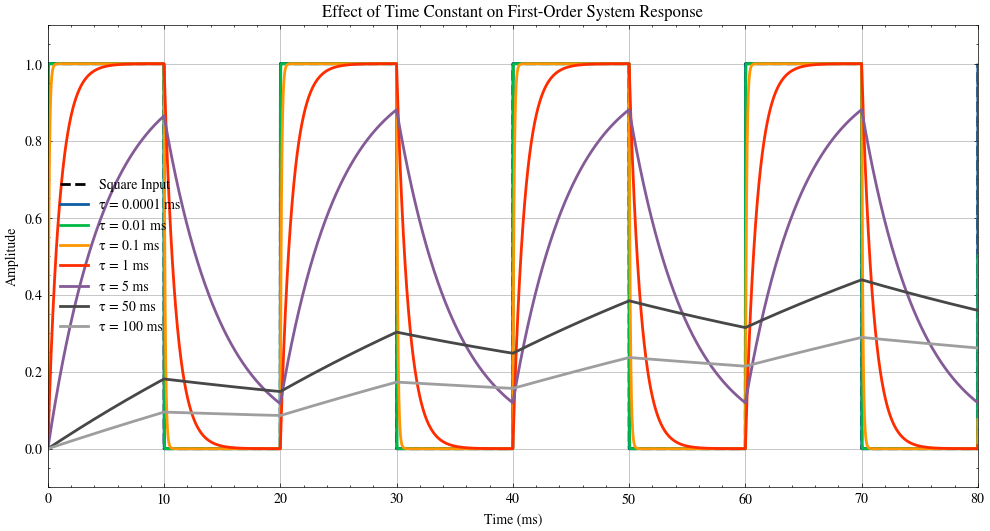

In [10]:
taus = [
    100e-9,
    10e-6,
    100e-6,
    1e-3,
    5e-3,
    50e-3,
    100e-3
]

plt.figure(figsize=(12,6))

plt.plot(t*1000, u, 'k--', linewidth=2, label='Square Input')

for tau in taus:
    system = signal.TransferFunction([1], [tau,1])
    _, y, _ = signal.lsim(system, U=u, T=t)

    plt.plot(t*1000, y, linewidth=2,
             label=f'τ = {tau*1000:g} ms')

plt.title("Effect of Time Constant on First-Order System Response")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.xlim(0,80)
plt.ylim(-0.1,1.1)

plt.show()